# Set Up

In [5]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, math, seaborn as sns
import plotly.express as px
import plotly.io as pio

In [66]:
mlb = pd.read_csv('mlb_teams.csv')
mlb['runs_scored'] = pd.to_numeric(mlb['runs_scored'], errors = 'coerce').fillna(0).astype(int)
mlb['team_name'] = mlb['team_name'].replace('Florida Marlins', 'Miami Marlins')
mlb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2784 entries, 0 to 2783
Data columns (total 41 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   year                    2784 non-null   int64  
 1   league_id               2784 non-null   object 
 2   division_id             1438 non-null   object 
 3   rank                    2784 non-null   int64  
 4   games_played            2784 non-null   int64  
 5   home_games              2556 non-null   float64
 6   wins                    2784 non-null   int64  
 7   losses                  2784 non-null   int64  
 8   division_winner         1410 non-null   object 
 9   wild_card_winner        774 non-null    object 
 10  league_winner           2756 non-null   object 
 11  world_series_winner     2536 non-null   object 
 12  runs_scored             2784 non-null   int64  
 13  at_bats                 2784 non-null   int64  
 14  hits                    2784 non-null   

In [67]:
# Data from only National League Teams
mlb_nl = mlb[(mlb['year'] >= 2010) & (mlb['year'] <= 2019) & (mlb['league_id'] == 'NL')]
mlb_nl.head()

,year,league_id,division_id,rank,games_played,home_games,wins,losses,division_winner,wild_card_winner,...,hits_allowed,homeruns_allowed,walks_allowed,strikeouts_by_pitchers,errors,double_plays,fielding_percentage,team_name,ball_park,home_attendance
2454,2010,NL,W,5,162,81.0,65,97,N,N,...,1503,210,548,1070,102,152,0.983,Arizona Diamondbacks,Chase Field,2056941.0
2455,2010,NL,E,2,162,81.0,91,71,N,Y,...,1326,126,505,1241,126,166,0.980,Atlanta Braves,Turner Field,2510119.0
2459,2010,NL,C,5,162,81.0,75,87,N,N,...,1409,154,605,1268,126,137,0.979,Chicago Cubs,Wrigley Field,3062973.0
2460,2010,NL,C,1,162,81.0,91,71,Y,N,...,1404,158,524,1130,72,142,0.988,Cincinnati Reds,Great American Ball Park,2060550.0
2462,2010,NL,W,3,162,81.0,83,79,N,N,...,1405,139,525,1234,101,182,0.984,Colorado Rockies,Coors Field,2875245.0


In [68]:
# NL Team Stats from 2019 Season
mlb_nl_2019 = mlb_nl[(mlb_nl['year'] == 2019)]
mlb_nl_2019.head()

,year,league_id,division_id,rank,games_played,home_games,wins,losses,division_winner,wild_card_winner,...,hits_allowed,homeruns_allowed,walks_allowed,strikeouts_by_pitchers,errors,double_plays,fielding_percentage,team_name,ball_park,home_attendance
2724,2019,NL,W,2,162,81.0,85,77,N,N,...,1400,220,516,1427,86,136,0.986,Arizona Diamondbacks,Chase Field,2135510.0
2725,2019,NL,E,1,162,81.0,97,65,Y,N,...,1421,203,548,1393,78,154,0.987,Atlanta Braves,SunTrust Park,2655100.0
2729,2019,NL,C,3,162,81.0,84,78,N,N,...,1376,195,534,1444,118,141,0.981,Chicago Cubs,Wrigley Field,3094865.0
2730,2019,NL,C,4,162,81.0,75,87,N,N,...,1270,214,536,1552,91,124,0.984,Cincinnati Reds,Great American Ball Park,1808685.0
2732,2019,NL,W,4,162,81.0,71,91,N,N,...,1576,270,589,1264,97,165,0.984,Colorado Rockies,Coors Field,2993244.0


# Dot Plot

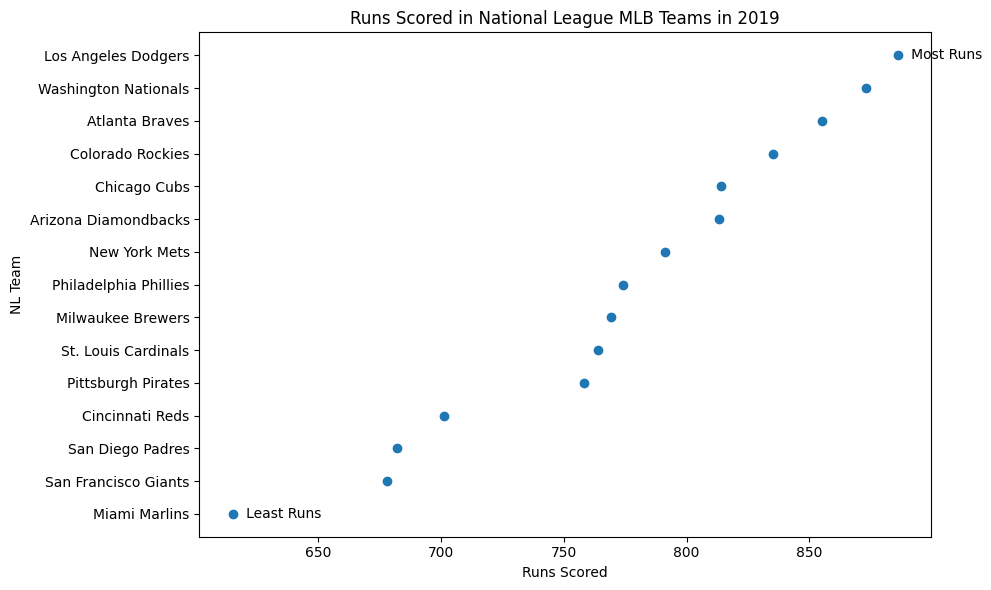

In [69]:
mlb_nl_2019 = mlb_nl_2019.sort_values(by = 'runs_scored', ascending = True)

plt.figure(figsize = (10,6))
y = np.arange(len(mlb_nl_2019))
plt.plot(mlb_nl_2019['runs_scored'], y, 'o')
plt.yticks(y, mlb_nl_2019['team_name'].values)
plt.xlabel("Runs Scored")
plt.ylabel("NL Team")
plt.title("Runs Scored in National League MLB Teams in 2019")
plt.text(mlb_nl_2019["runs_scored"].iloc[-1], y[-1], "   Most Runs", va="center")
plt.text(mlb_nl_2019["runs_scored"].iloc[0],  y[0],  "   Least Runs", va="center")
plt.tight_layout()
plt.show()

# Slope Chart

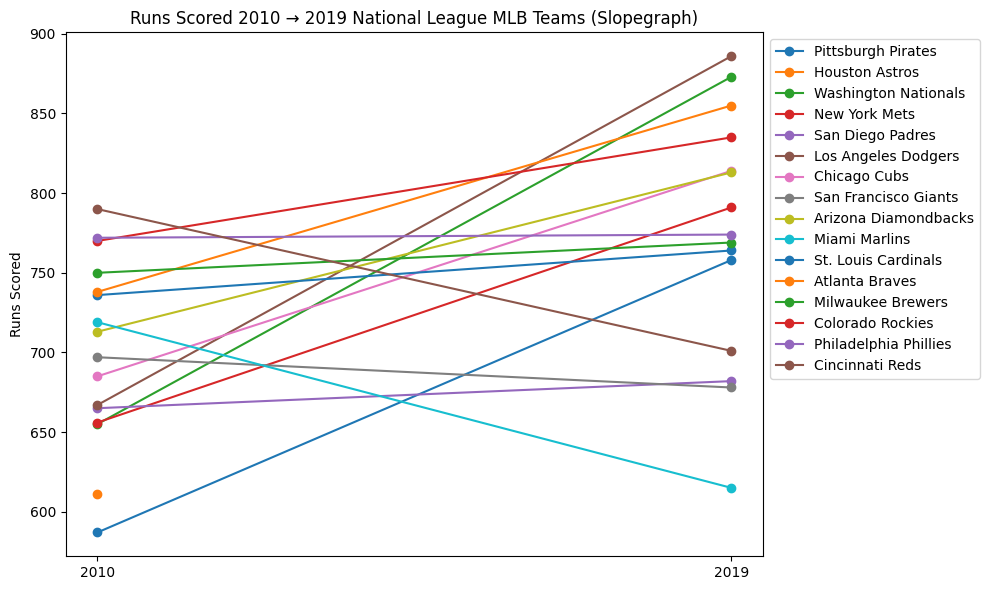

In [70]:
s0 = 2010
s1 = 2019

mlb_piv = mlb_nl.pivot(index = 'team_name', columns = 'year', values = 'runs_scored')

mlb_piv = mlb_piv.sort_values(by = s0, ascending = True)

plt.figure(figsize=(10, 6))

for t in mlb_piv.index:
    plt.plot([0,1], [mlb_piv.loc[t, s0], mlb_piv.loc[t, s1]], marker='o', label = t)
plt.xticks([0,1], [s0, s1])
plt.ylabel("Runs Scored")
plt.title(f"Runs Scored {s0} → {s1} National League MLB Teams (Slopegraph)")
plt.legend(bbox_to_anchor = (1, 1), loc = 'upper left')
plt.tight_layout()
plt.show()


# Small-Multiples Chart

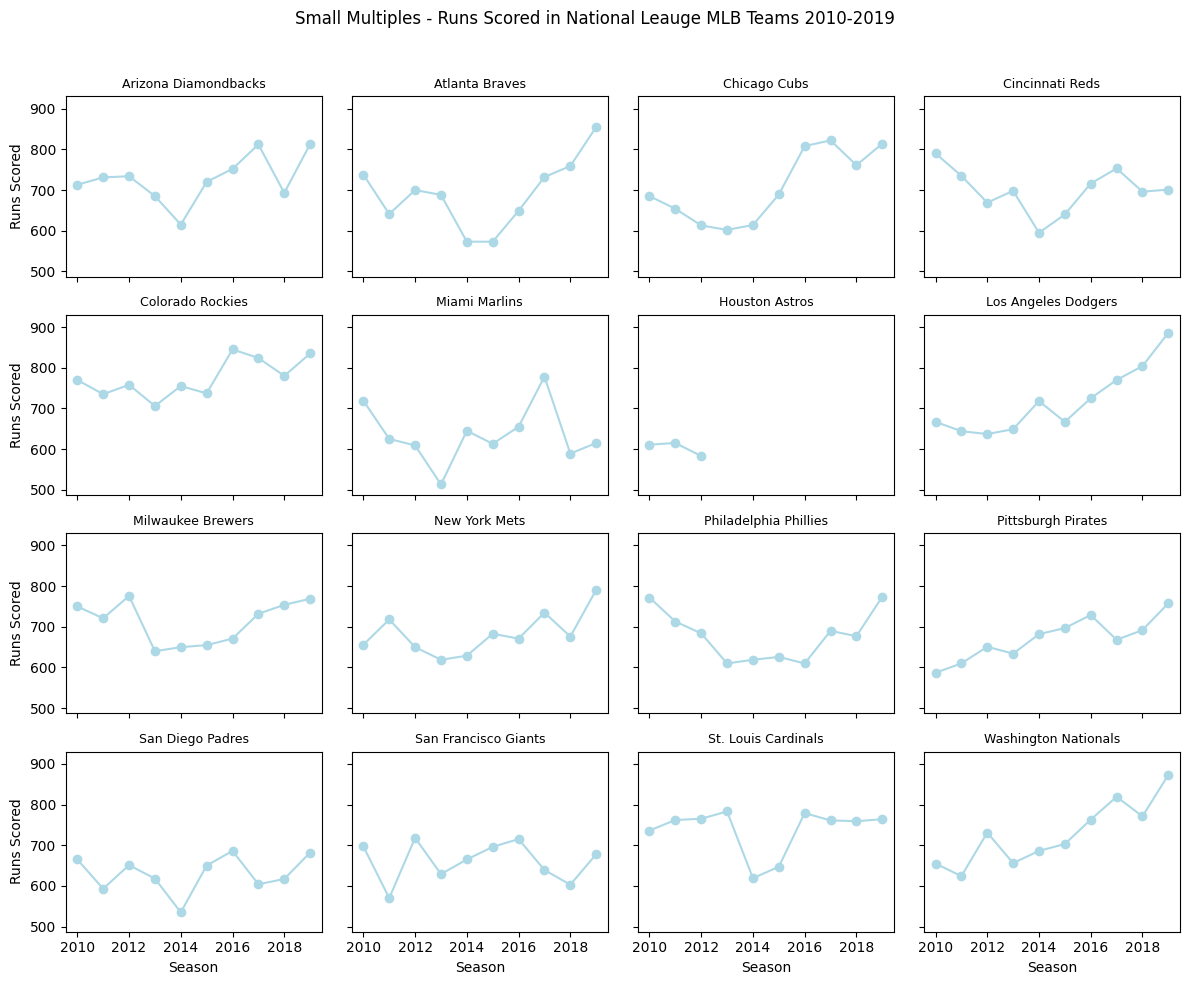

In [71]:
teams = mlb_nl['team_name'].unique()

n, cols = len(teams), 4
rows = math.ceil(n/cols)

fig, axes = plt.subplots(rows, cols, figsize = (3 * cols, 2.5 * rows), sharex = True, sharey = True)
axes = axes.flatten()

ymin = mlb_nl['runs_scored'].min() * 0.95
ymax = mlb_nl['runs_scored'].max() * 1.05

for i, t in enumerate(teams):
    ax = axes[i]
    team_data = mlb_nl[mlb_nl['team_name'] == t]
    ax.plot(team_data['year'], team_data['runs_scored'], marker = 'o', color = 'lightblue')

    ax.set_title(t, fontsize = 9)
    ax.set_ylim(ymin, ymax)

    r, c = divmod(i, cols)
    if r == rows - 1:
        ax.set_xlabel("Season")
    if c == 0:
        ax.set_ylabel("Runs Scored")

for j in range (i + 1, rows * cols):
    axes[j].set_visible(False)

fig.suptitle("Small Multiples - Runs Scored in National Leauge MLB Teams 2010-2019", y = 0.98, fontsize = 12)
fig.tight_layout(rect = [0, 0, 1, 0.96])
plt.show()

# Normalized View

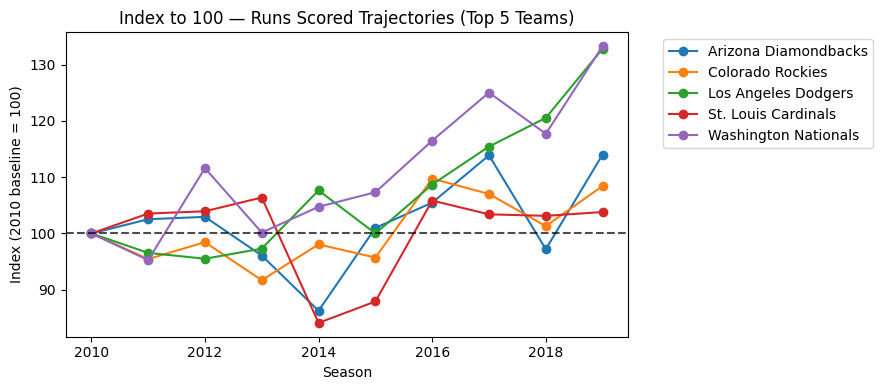

In [74]:
watch = (mlb_nl.groupby('team_name')['runs_scored'].sum()
         .sort_values(ascending = False).head(5).index.tolist())

pivot = mlb_nl[mlb_nl['team_name'].isin(watch)] \
    .pivot(index = 'year', columns = 'team_name', values = 'runs_scored')

indexed = pivot.apply(lambda s: (s / s.iloc[0]) * 100)

plt.figure(figsize =(9,4))

for t in indexed.columns:
    s = indexed[t].dropna()
    plt.plot(s.index, s.values, marker = 'o', label = t)

plt.axhline(100, linestyle='--', color='black', alpha=0.7)

plt.xlabel("Season")
plt.ylabel("Index (2010 baseline = 100)")
plt.title("Index to 100 — Runs Scored Trajectories (Top 5 Teams)")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.tight_layout()
plt.show()

# Summary

My comparison question was to address which team in the MLB's National League scored the most runs between 2010 and 2019. Among all four graphs, the dot plot best shows how each individual team did in comparison to the others. In this graph, it is much easier to see who was the top run scorer and the bottom run scorer. The Small Multiples chart best shows the trajectory of the runs scored by each team in the National League of the MLB, but it is much harder to understand how each team did in comparison to the others. It is more useful to use the Small Multiples chart to see how each National League team did on an individual level. The Slope Chart is good to understand generic trends, but the overlapping lines make it too hard to really see what is going on. The Normalized View does a better job than the Slope Chart and Small Multiples Charts, but since it only considers the top 5 teams in the National League, it is not fully representative of all 15 teams. 